<a href="https://colab.research.google.com/github/PeterShiaush/ColabYolo26/blob/main/TPU_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 逐步執行以下:

1.   點擊上面的「**Open in Colab**」的連結
2.   再點擊上面  **複製到雲端硬碟**，成為**自己的colab 檔案**
3.   再**左上角** 修改檔名  : **推論TPU_01.ipynb**
4.   右上角，輪圈(設定): 編輯器，**顯示行號**

---

# Inference 推論


*   TPU（張量處理單元）的 **推論（Inference）** 是指使用已經訓練好的模型 best.pt，yolo26n.pt or ....，對新數據進行預測或分析的過程。
*   相較於通用型 GPU，TPU 是專門為機器學習設計的 ASIC（特殊應用積體電路），在執行大規模張量運算時具有極高的吞吐量與能源效率。

---

## 使用**免費**的 GPU，TPU，不一定可以，最後優先，除非**月繳費**

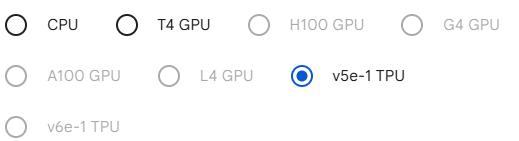




*   **MYYA**，請放自己的YA自拍
*   **YA_Web**，請放 網路取得的YA相片



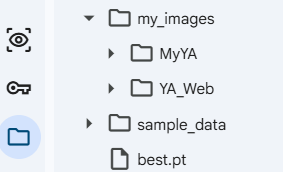

In [ ]:
import os
!pip install ultralytics # 如果還沒安裝 ultralytics 函式庫，這行會幫你安裝
from ultralytics import YOLO # 從 ultralytics 函式庫中導入 YOLO 模型 (偵測物件的工具)
import cv2 # 導入 OpenCV 函式庫，用來處理圖片和影片
from google.colab.patches import cv2_imshow # 這是 Colab 專用的工具，讓 OpenCV 處理的圖片能在 Colab 裡顯示
from google.colab import files # 導入 files 模組，讓我們可以從電腦上傳檔案到 Colab

# 這個程式碼區塊的目標是：
# 1. 載入我們已經訓練好的物件偵測模型 (YOLO)。
# 2. 讓你從自己的電腦上傳圖片或影片。
# 3. 使用模型對上傳的內容進行分析，找出其中有沒有特定物件。
# 4. 把分析結果顯示出來。

# 1. 載入已經訓練好的模型 (就像給電腦一個「最強大腦」)
# 這裡載入的是一個名為 'best.pt' 的檔案，裡面包含了模型學習到的知識。
model??? = YOLO('/content/best.pt')

# 創建一個專門的資料夾來暫時存放你上傳的檔案
# 這樣做可以讓檔案管理更整齊，不會和 Colab 裡的其他檔案混在一起。
upload_dir??? = "/content/uploaded_media"
os.makedirs(upload_dir, exist_ok=True) # 如果資料夾已經存在，就不用再創建一次
print(f"準備上傳檔案，將會儲存到：{upload_dir}")

# 2. 從你的電腦上傳照片或影片
print("\n請上傳您想要進行辨識的圖片檔案：")
# files.upload() 會打開一個檔案選擇視窗，讓你選取檔案。
# 注意：當你上傳檔案後，Colab 會先將檔案存到預設的 /content/ 目錄(但會有晚出現的現象)，
# 然後我們再把它們移動或複製到我們指定的 upload_dir。這是正常現象。
uploaded??? = files.upload()

uploaded_media_paths = [] # 建立一個清單，用來存放所有上傳檔案的完整路徑
# 處理每一個你上傳的檔案
for filename, content in uploaded.items():
  # 組合出, 檔案在 Colab 裡的完整路徑
  file_path = os.path.join(upload_dir, filename)
  # 把上傳的檔案內容寫入到我們指定的新路徑中
  with open(file_path, 'wb') as f:
    f.write(content)
  uploaded_media_paths.append(file_path) # 把檔案路徑加到清單裡
  print(f"檔案 \"{filename}\" 已儲存到 {file_path}")

# 檢查是否有檔案被上傳
if not uploaded_media_paths:
  print("沒有檔案被上傳。請上傳圖片以進行辨識。")
else:
  # 3. 對上傳的檔案進行「推理」(Inference)，也就是讓模型去辨識物件並顯示結果
  print("\n正在對上傳的內容進行辨識...")
  # 逐一處理清單中的每個檔案
  for media_path in uploaded_media_paths:
    print(f"\n處理檔案：{media_path}")

    # 檢查檔案的類型 (副檔名) 是不是圖片
    file_extension = os.path.splitext(media_path)[1].lower() # 取得副檔名並轉為小寫
    if file_extension in ['.jpg', '.jpeg', '.png', '.bmp', '.tiff']:
      # 如果是圖片，就用模型進行辨識
      # source=media_path: 指定要辨識的圖片路徑
      # conf=0.1: 只有當模型對偵測到的物件有 10% 以上的信心度時，才會顯示出來
      # imgsz=640: 將圖片大小調整為 640x640 像素進行辨識，這樣可以提高辨識速度和效果
      # stream=False: 表示一次性處理完圖片，而不是以串流方式處理
      results = model.predict(source=media_path, conf=0.1, imgsz=640, stream=False)
      # 檢查是否有辨識結果，並且結果可以被繪製出來
      if results and any(hasattr(r, 'plot') for r in results):
          print(f"顯示 {os.path.basename(media_path)} 的辨識結果：")
          res_plotted = results[0].plot() # 將偵測到的物件和邊界框繪製到圖片上
          cv2_imshow(res_plotted) # 在 Colab 中顯示處理後的圖片
      else:
          print(f"圖片 {media_path} 未偵測到任何物件，或無法顯示結果。")
    else:
      # 如果檔案不是支援的圖片格式
      print(f"不支援的檔案類型：{file_extension}。目前此程式碼區塊僅支援圖片格式。")

# 這裡移除了原本註解掉的刪除暫存資料夾的程式碼，如果需要刪除，可以另外執行。

In [9]:
# 檢查 upload_dir = "/content/uploaded_media" 目錄中的檔案
import os
print(f"以下是 '{upload_AAA}' 目錄中的檔案：")
if os.path.exists(upload_AAA):
    for filename in os.listdir(upload_AAA):
        print(f"- {filename}")
else:
    print(f"目錄 '{upload_dir}' 不存在。")

NameError: name 'upload_AAA' is not defined

## 影片即時偵測與儲存

這段程式碼將會：
1. 讀取您先前上傳的影片檔。
2. 對影片的每一幀進行物件偵測。
3. 將偵測結果（邊界框和類別標籤）繪製到每一幀上。
4. 將處理後的幀寫入一個新的影片檔。
5. 在 Colab 中顯示處理後的影片，並提供下載連結。

In [31]:
uploaded_mp4_paths = ['/content/test999.mp4','/content/Video999.mp4']
print(f"設定要處理的影片為：{uploaded_mp4_paths[0]}")

設定要處理的影片為：/content/test999.mp4


In [32]:
import os

# 使用 uploaded_mp4_paths 列表中的第一個影片檔案路徑
video_to_check = uploaded_mp4_paths[0]
if os.path.exists(video_to_check):
    print(f"檔案 '{video_to_check}' 存在。")
else:
    print(f"檔案 '{video_to_check}' 不存在。請確認您已將影片檔案上傳到 Colab 的 /content/ 目錄。")

檔案 '/content/test999.mp4' 不存在。請確認您已將影片檔案上傳到 Colab 的 /content/ 目錄。


In [33]:
import os
import cv2
from IPython.display import HTML, display, Video # 導入 IPython.display 以便在 Colab 中顯示影片
from google.colab import files # 導入 files 模組用於檔案上傳，讓你能上傳或下載檔案

# --- 確保物件偵測模型和資料夾已準備好 --- #

# 檢查物件偵測模型 (model) 是否已經載入。
# 如果沒有載入，就重新載入，因為我們需要它來識別影片中的物件。
if 'model' not in locals():
    print("正在載入物件偵測模型... (這個步驟可能在上一個程式碼區塊已經完成)")
    from ultralytics import YOLO # 只有在模型還沒載入時，才匯入 YOLO 函式庫
    model = YOLO('/content/best.pt') # 載入我們預先訓練好的物件偵測模型檔案

# 檢查用來存放上傳和處理後檔案的資料夾 (upload_dir) 是否已經定義。
# 如果這個資料夾不存在，就先建立它，確保我們有地方可以儲存檔案。
if 'upload_dir' not in locals():
    upload_dir = "/content/uploaded_media" # 設定檔案儲存的目錄名稱
    os.makedirs(upload_dir, exist_ok=True) # 建立這個目錄，如果它已經存在則不做任何事

# --- 開始處理影片檔案 --- #

# 遍歷 uploaded_mp4_paths 列表中的所有影片路徑。
# 這個列表包含了你希望進行物件偵測的所有影片檔案。
for video_file_path in uploaded_mp4_paths:
    # 取得影片檔案的副檔名 (例如 '.mp4', '.avi')，並轉為小寫方便檢查
    file_extension = os.path.splitext(video_file_path)[1].lower()

    # 檢查這個檔案是不是我們支援的影片格式
    if file_extension in ['.mp4', '.avi', '.mov', '.mkv']:
        print(f"\n正在處理影片：{video_file_path}")

        # 使用 OpenCV 打開影片檔案，準備讀取影片中的每一張畫面 (幀)
        video_reader = cv2.VideoCapture(video_file_path)
        # 檢查影片是否成功打開
        if not video_reader.isOpened():
            print(f"錯誤：無法打開影片檔案 {video_file_path}。請檢查檔案是否存在或損壞。")
            continue # 跳過這個檔案，處理下一個影片

        # 獲取影片的一些基本資訊，例如畫面的寬度、高度、每秒幀數 (fps) 和總共的幀數
        frame_width = int(video_reader.get(cv2.CAP_PROP_FRAME_WIDTH))
        frame_height = int(video_reader.get(cv2.CAP_PROP_FRAME_HEIGHT))
        frames_per_second = int(video_reader.get(cv2.CAP_PROP_FPS))
        total_frames = int(video_reader.get(cv2.CAP_PROP_FRAME_COUNT))

        # 設定輸出影片的檔案名稱和儲存路徑
        output_video_name = f"output_{os.path.basename(video_file_path)}" # 新影片檔名加上 'output_' 前綴
        output_video_path = os.path.join(upload_dir, output_video_name) # 處理後的影片將儲存在此路徑

        # 設定影片的編碼器，這裡使用 'mp4v' 編碼，它常用於 .mp4 影片
        video_codec = cv2.VideoWriter_fourcc(*'mp4v')
        # 建立一個物件來寫入處理後的影片到新的檔案中
        video_writer = cv2.VideoWriter(output_video_path, video_codec, frames_per_second, (frame_width, frame_height))

        # 檢查輸出影片檔案是否成功建立
        if not video_writer.isOpened():
            print(f"錯誤：無法建立輸出影片檔 {output_video_path}。請檢查路徑或權限設定。")
            video_reader.release() # 釋放影片讀取資源
            continue # 跳過這個檔案，處理下一個影片

        print(f"影片總幀數：{total_frames} 幀，每秒顯示幀數：{frames_per_second} FPS")
        processed_frames_count = 0 # 用來計算已經處理了多少幀畫面

        # --- 逐一處理影片中的每一張畫面 (幀) --- #
        while True:
            # 讀取影片的下一幀畫面
            read_success, current_frame = video_reader.read()
            # 如果沒有更多畫面可以讀取了 (read_success 為 False)，就代表影片已經播放完畢，跳出迴圈
            if not read_success:
                break

            # 使用物件偵測模型對當前畫面 (current_frame) 進行預測
            # conf=0.2: 只有當模型對偵測到的物件有 20% 以上的信心度時，才會顯示出來 (例如：只有超過20%確定是狗才會標示出來)
            # imgsz=640: 將圖片大小調整為 640x640 像素進行辨識，這樣可以提高辨識速度和效果
            # verbose=False: 不顯示詳細的偵測過程訊息，讓輸出更簡潔
            detection_results = model.predict(source=current_frame, conf=0.2, imgsz=640, verbose=False)

            # 將偵測到的物件（例如邊界框和類別標籤）繪製到畫面上
            if detection_results and any(hasattr(r, 'plot') for r in detection_results):
                # 取得繪製了偵測結果的畫面
                frame_with_detections = detection_results[0].plot()
            else:
                # 如果沒有偵測到任何物件，就直接使用原始畫面
                frame_with_detections = current_frame.copy()

            # 將處理後的畫面寫入到新的影片檔案中
            video_writer.write(frame_with_detections)
            processed_frames_count += 1 # 已處理的幀數加一

            # 每處理一定的幀數 (例如每30幀)，就印出進度訊息，讓你了解目前的處理進度
            if processed_frames_count % 30 == 0:
                print(f"已處理 {processed_frames_count}/{total_frames} 幀畫面...")

        print(f"所有 {processed_frames_count} 幀畫面已處理完畢。處理後的影片已儲存至：{output_video_path}")

        # --- 釋放影片讀取和寫入的資源 --- #
        video_reader.release() # 釋放影片讀取物件的資源
        video_writer.release() # 釋放影片寫入物件的資源

        # --- 檢查結果並提供下載 --- #
        # 檢查輸出影片檔案是否確實生成，並且檔案大小不為零 (確保檔案內容完整)
        if os.path.exists(output_video_path) and os.path.getsize(output_video_path) > 0:
            print(f"輸出影片檔案 '{output_video_name}' 已成功生成，檔案大小為 {os.path.getsize(output_video_path)} 位元組。")
            print(f"注意：目前無法在 Colab 介面中直接嵌入顯示處理後的影片：{output_video_name}")

            # 提供下載連結，方便你將處理後的影片下載到自己的電腦上
            print(f"您可以點擊下方連結下載處理後的影片：")
            files.download(output_video_path) # 這會生成一個下載按鈕或連結
        else:
            print(f"錯誤：輸出影片檔案 '{output_video_name}' 生成失敗或為空。請檢查處理過程是否有誤。")

    else:
        print(f"檔案 {video_file_path} 不是支援的影片格式，已跳過處理。目前僅支援 MP4, AVI, MOV, MKV 等格式。")

print("所有影片處理完成！")


正在處理影片：/content/test999.mp4
錯誤：無法打開影片檔案 /content/test999.mp4。請檢查檔案是否存在或損壞。

正在處理影片：/content/Video999.mp4
錯誤：無法打開影片檔案 /content/Video999.mp4。請檢查檔案是否存在或損壞。
所有影片處理完成！
